In [3]:
import os
import glob
import seaborn as sns
import re
import pandas as pd
import plotly.express as px
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# hbn-specific libraries - make sure you have installed (pipenv install) and activated (pipenv shell) 
# the virtual environment for this project, and make sure you have created an ipykernel for this environment (ipython kernel install --name "hbn" --user)
from hbn.constants import Defaults
from hbn.scripts import preprocess_phenotype, make_phenotype_specs
from hbn.data import make_dataset
from hbn.features import build_features
from hbn.features.feature_selection import phenotype_features

%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [154]:
# RUN THIS CELL
# FUNCTIONS

def load_data(
    participants, 
    feature_spec, 
    cols_to_keep=['DX_01', 'DX_01_Cat', 'Age', 'Sex', 'Identifiers']
    ):
    # get data
    df = phenotype_features(target_spec=None,
                            feature_spec=os.path.join(Defaults.FEATURE_DIR, feature_spec),
                            participants=participants,
                            preprocess=False,
                            drop_identifiers=False
                            )
    
    # get summary of clinical diagnosis + other demographics
    dx = make_dataset.make_summary(save=False)
    dx = make_dataset._add_race_ethnicity(dataframe=dx)

    # get data from intake interview and merge with clinical summary
    df = df.merge(dx[cols_to_keep], on='Identifiers')
    
    return df

def make_dataframe(
    feature_spec,
    participants,
    cols_to_keep='Identifiers|DX_01|Age|Sex|DX_01_Cat',
    filter_scores=True,
    ):

    # get data
    list_of_cols = list(cols_to_keep.split('|'))
    df = load_data(participants, 
                 feature_spec=feature_spec,
                 cols_to_keep=list_of_cols
                 )
    
    # get assessment, domain, measure names
    feature_spec_split = Path(feature_spec).name.split('-')
    assessment, domain, measure = feature_spec_split[1], feature_spec_split[2], '-'.join(feature_spec_split[3:-1])
    
    df_all = pd.DataFrame()
    if len(df.columns) > len(list_of_cols): 
        
        # get abbrev from dataframe based on default columns
        dict_present = False
        abbrev = df.filter(regex='Site|EID|START_DATE|Data_entry|Year').columns[0].split(',')[0]
        fpath = os.path.join(Defaults.PHENO_DIR, 'Release9_DataDic', abbrev + '.xlsx')
        if os.path.isfile(fpath):
            dict_df = pd.read_excel(fpath, header=1)
            dict_present = True
        
        # only process data that have accompanying dictionaires
        if dict_present:

            # remove prefix from variable values - always second column in data dic
            dict_df.rename(columns={dict_df.columns[0]: "Question", dict_df.columns[1]: "Variable"}, inplace=True)

            # filter dataframe on certain columns and regex patterns
            df_filter = df.filter(regex=f'{abbrev}|{cols_to_keep}')

            # loop over diagnosis groups and melt `T_scores` column into one
            # concat each group to one dataframe
            for name, group in df_filter.groupby('DX_01'):
                if filter_scores:
                    scores_to_filter = '_T|_Stnd|_Sum|_Score|_Scale|_Standard|_IN|_HY'
                    group = group.filter(regex=f'{scores_to_filter}|{cols_to_keep}')
                tmp = group.melt(id_vars=list(cols_to_keep.split('|'))).rename({'variable':'Name', 'value': 'Scores'}, axis=1)
                tmp['Name'] = tmp['Name'].str.replace(f'{abbrev},','')
                tmp = tmp.merge(dict_df[['Question', 'Variable']], left_on=['Name'], right_on=['Variable'])
                tmp['Assessment'], tmp['domain'], tmp['measure'] = assessment, domain, measure
                df_all = pd.concat([tmp, df_all])

            # do some clean up on existing columns
            df_all['Age_rounded'] = df_all['Age'].round()
            df_all['Question'] = df_all['Question'].str.replace("T Score", "T-Score")
        
    
    return df_all.reset_index(drop=True)


def get_data(domain):
    
    participants = make_dataset.get_participants(
                                split='all', 
                                disorders=['ADHD-Combined Type', 
                                            'ADHD-Inattentive Type', 
                                            'ADHD-Hyperactive_Impulsive_Type', 
                                            'Other_Specified_Attention-Deficit_Hyperactivity_Disorder',
                                            'No_Diagnosis_Given']
                                            )
    # loop over domains
    feature_specs = glob.glob(os.path.join(Defaults.FEATURE_DIR, f'*{domain}*'))

    # loop over feature specs 
    df_all = pd.DataFrame()
    for feature_spec in feature_specs:
        df = make_dataframe(
                            feature_spec=feature_spec,
                            participants=participants,
                            cols_to_keep='Identifiers|DX_01|Age|Sex|DX_01_Cat',
                            filter_scores=True,
                            )
        df_all = pd.concat([df_all, df])
        print(feature_spec)
    
    return df_all


In [15]:
## RUN THIS CELL ##

# Preprocess data
#preprocess_phenotype.run()

# get specs
#make_phenotype_specs.run()

/Users/maedbhking/Documents/healthy_brain_network/features/features-Child_Measures-Physical_Fitness_and_Status-Edinburgh_Handedness-spec.json
/Users/maedbhking/Documents/healthy_brain_network/features/features-Child_Measures-Physical_Fitness_and_Status-Body_Composition-spec.json
/Users/maedbhking/Documents/healthy_brain_network/features/features-Child_Measures-Physical_Fitness_and_Status-Physical_Activity_Questionnaire_for_Adolescents_-spec.json
/Users/maedbhking/Documents/healthy_brain_network/features/features-Child_Measures-Physical_Fitness_and_Status-FitnessGram-spec.json
/Users/maedbhking/Documents/healthy_brain_network/features/features-Child_Measures-Physical_Fitness_and_Status-Food_Frequency_Questionnaire-Screening_Form-spec.json
/Users/maedbhking/Documents/healthy_brain_network/features/features-Child_Measures-Physical_Fitness_and_Status-Treadmill_Test-spec.json
/Users/maedbhking/Documents/healthy_brain_network/features/features-Child_Measures-Physical_Fitness_and_Status-Physi

In [61]:
domains = build_features.get_domains(assessment=assessment)
domains[assessment].remove('all')
domains = [os.path.join('_'.join(re.split(r'_|,|/| ', d))) for d in domains[assessment]]
print(domains)

['Cognitive_Testing', 'Language_Tasks', 'Interview_of_Emotional_and_Psychological_Function', 'Neurologic_Function', 'Physiologic_Function', 'Physical_Fitness_and_Status', 'Motor_Skills', 'Vision', 'Medical_Status__Measures', 'Questionnaire_Measures_of_Emotional_and_Cognitive_Status', 'Questionnaire_Measures_of_Substance_Use__&_Addiction_', 'Questionnaire_Measures_of_Family_Structure__Stress__and_Trauma']


## Physical Fitness and Status

In [ ]:
df = get_data(domain='Physical_Fitness_and_Status')

for name, group in df.groupby(['Question']):
    
    measure = group['measure'].unique()[0]
    
    fig = sns.barplot(data=group, x='Question', y='Scores', hue='DX_01')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks([]);
    plt.xlabel('')
    plt.title(f'{measure}-{name}')
    plt.show()

for name, group in df.groupby(['Question']):

    tmp = group.groupby(['DX_01', 'Sex']).mean().reset_index()

    fig = px.line_polar(tmp, r="Scores", 
                        theta="DX_01", 
                        color="Sex", 
                        line_close=True, 
                        title=f'{measure}-{name}',
                        range_r=[tmp['Scores'].min(), tmp['Scores'].max()]
                       ) 
    fig.show()

## Cognitive Testing 

In [ ]:
df = get_data(domain='Cognitive_Testing')

for name, group in df.groupby(['Question']):
    
    measure = group['measure'].unique()[0]
    
    fig = sns.barplot(data=group, x='Question', y='Scores', hue='DX_01')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks([]);
    plt.xlabel('')
    plt.title(f'{measure}-{name}')
    plt.show()

for name, group in df.groupby(['Question']):

    tmp = group.groupby(['DX_01', 'Sex']).mean().reset_index()

    fig = px.line_polar(tmp, r="Scores", 
                        theta="DX_01", 
                        color="Sex", 
                        line_close=True, 
                        title=f'{measure}-{name}',
                        range_r=[tmp['Scores'].min(), tmp['Scores'].max()]
                       ) 
    fig.show()

## Language Tasks

In [ ]:
df = get_data(domain='Language_Tasks')

for name, group in df.groupby(['Question']):
    
    measure = group['measure'].unique()[0]
    
    group = group.dropna(how='any')
    
    try:
        group['Scores'] = group['Scores'].astype(int)
    except:
        group['Scores'] = group['Scores'].factorize()[0] + 1
    
    tmp = group.groupby(['DX_01', 'Sex']).mean().reset_index()
    
    fig = sns.barplot(data=group, x='Question', y='Scores', hue='DX_01')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks([]);
    plt.xlabel('')
    plt.title(f'{measure}-{name}')
    plt.show()


for name, group in df.groupby(['Question']):
    
    group = group.dropna(how='any')
    
    try:
        group['Scores'] = group['Scores'].astype(int)
    except:
        group['Scores'] = group['Scores'].factorize()[0] + 1
    
    tmp = group.groupby(['DX_01', 'Sex']).mean().reset_index()

    fig = px.line_polar(tmp, r="Scores", 
                        theta="DX_01", 
                        color="Sex", 
                        line_close=True, 
                        title=f'{measure}-{name}',
                        range_r=[tmp['Scores'].min(), tmp['Scores'].max()]
                       ) 
    fig.show()

## Interview_of_Emotional_and_Psychological_Function

In [137]:
df = get_data(domain='Interview_of_Emotional_and_Psychological_Function')

for name, group in df.groupby(['Question']):
    
    measure = group['measure'].unique()[0]
    
    group = group.dropna(how='any')
    
    try:
        group['Scores'] = group['Scores'].astype(int)
    except:
        group['Scores'] = group['Scores'].factorize()[0] + 1
    
    tmp = group.groupby(['DX_01', 'Sex']).mean().reset_index()
    
    fig = sns.barplot(data=group, x='Question', y='Scores', hue='DX_01')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks([]);
    plt.xlabel('')
    plt.title(f'{measure}-{name}')
    plt.show()
    

for name, group in df.groupby(['Question']):
    
    group = group.dropna(how='any')
    
    try:
        group['Scores'] = group['Scores'].astype(int)
    except:
        group['Scores'] = group['Scores'].factorize()[0] + 1
    
    tmp = group.groupby(['DX_01', 'Sex']).mean().reset_index()

    fig = px.line_polar(tmp, r="Scores", 
                        theta="DX_01", 
                        color="Sex", 
                        line_close=True, 
                        title=f'{measure}-{name}',
                        range_r=[tmp['Scores'].min(), tmp['Scores'].max()]
                       ) 
    fig.show()

/Users/maedbhking/Documents/healthy_brain_network/features/features-Child_Measures-Interview_of_Emotional_and_Psychological_Function-Kiddie_Schedule_for_Affective_Disorders_and_Schizophrenia-spec.json
/Users/maedbhking/Documents/healthy_brain_network/features/features-Parent_Measures-Interview_of_Emotional_and_Psychological_Function-Pregnancy_and_Birth_Questionnaire-spec.json
/Users/maedbhking/Documents/healthy_brain_network/features/features-Parent_Measures-Interview_of_Emotional_and_Psychological_Function-Intake_Interview_PreInt_EduHx-spec.json
/Users/maedbhking/Documents/healthy_brain_network/features/features-Parent_Measures-Interview_of_Emotional_and_Psychological_Function-Intake_Interview_PreInt_FamHx-spec.json
/Users/maedbhking/Documents/healthy_brain_network/features/features-Parent_Measures-Interview_of_Emotional_and_Psychological_Function-Intake_Interview_PreInt_Lang-spec.json
/Users/maedbhking/Documents/healthy_brain_network/features/features-Parent_Measures-Interview_of_Emo

## Vision

/Users/maedbhking/Documents/healthy_brain_network/features/features-Child_Measures-Vision-Ishihara_Color_Vision_Test-spec.json


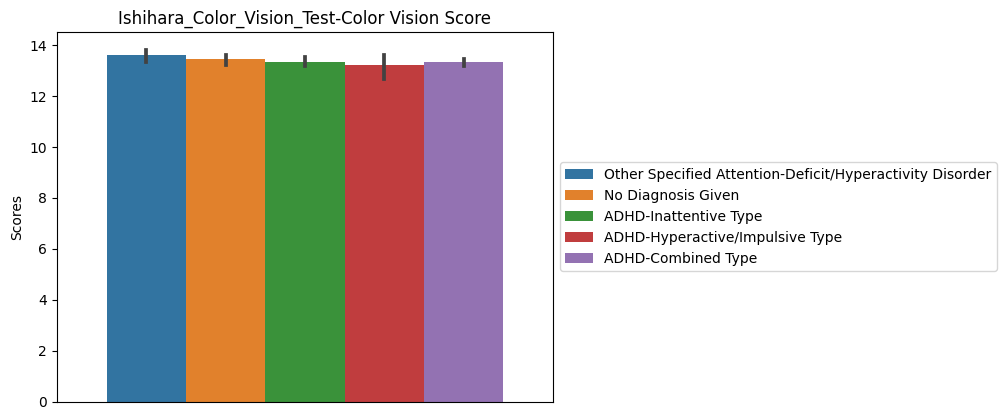

In [144]:

df = get_data(domain='Vision')

for name, group in df.groupby(['Question']):
    
    measure = group['measure'].unique()[0]
    
    group = group.dropna(how='any')
    
    try:
        group['Scores'] = group['Scores'].astype(int)
    except:
        group['Scores'] = group['Scores'].factorize()[0] + 1
    
    tmp = group.groupby(['DX_01', 'Sex']).mean().reset_index()
    
    fig = sns.barplot(data=group, x='Question', y='Scores', hue='DX_01')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks([]);
    plt.xlabel('')
    plt.title(f'{measure}-{name}')
    plt.show()
    

for name, group in df.groupby(['Question']):
    
    group = group.dropna(how='any')
    
    try:
        group['Scores'] = group['Scores'].astype(int)
    except:
        group['Scores'] = group['Scores'].factorize()[0] + 1
    
    tmp = group.groupby(['DX_01', 'Sex']).mean().reset_index()

    fig = px.line_polar(tmp, r="Scores", 
                        theta="DX_01", 
                        color="Sex", 
                        line_close=True, 
                        title=f'{measure}-{name}',
                        range_r=[tmp['Scores'].min(), tmp['Scores'].max()]
                       ) 
    fig.show()

## Questionnaire_Measures_of_Emotional_and_Cognitive_Status

/Users/maedbhking/Documents/healthy_brain_network/features/features-Child_Measures-Questionnaire_Measures_of_Emotional_and_Cognitive_Status-WHO_Disability_Assessment_Schedule_–_Self_Report-spec.json
/Users/maedbhking/Documents/healthy_brain_network/features/features-Child_Measures-Questionnaire_Measures_of_Emotional_and_Cognitive_Status-Conners_ADHD_Rating_Scales_-_Self_Report__Short_Form-spec.json
/Users/maedbhking/Documents/healthy_brain_network/features/features-Child_Measures-Questionnaire_Measures_of_Emotional_and_Cognitive_Status-Columbia_Suicide_Severity_Rating_Scale-spec.json
/Users/maedbhking/Documents/healthy_brain_network/features/features-Child_Measures-Questionnaire_Measures_of_Emotional_and_Cognitive_Status-The_Columbia_Impairment_Scale-Self_Report_Version-spec.json
/Users/maedbhking/Documents/healthy_brain_network/features/features-Child_Measures-Questionnaire_Measures_of_Emotional_and_Cognitive_Status-Adult_Self_Report_-spec.json
/Users/maedbhking/Documents/healthy_brai

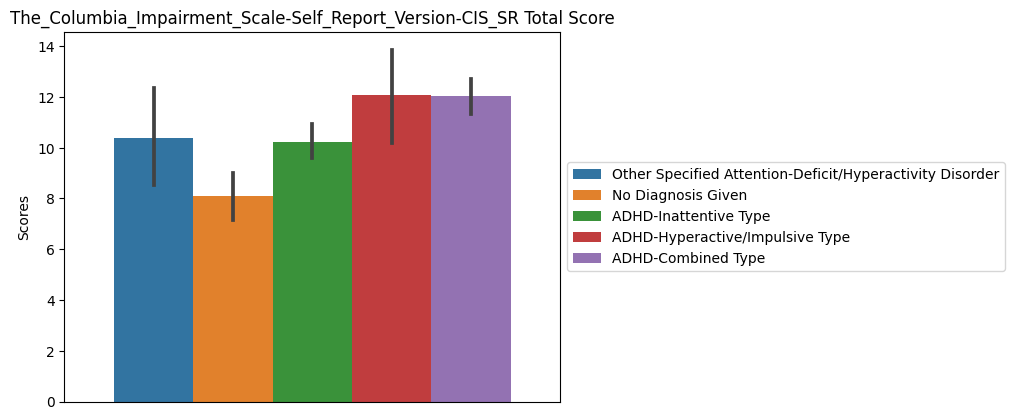

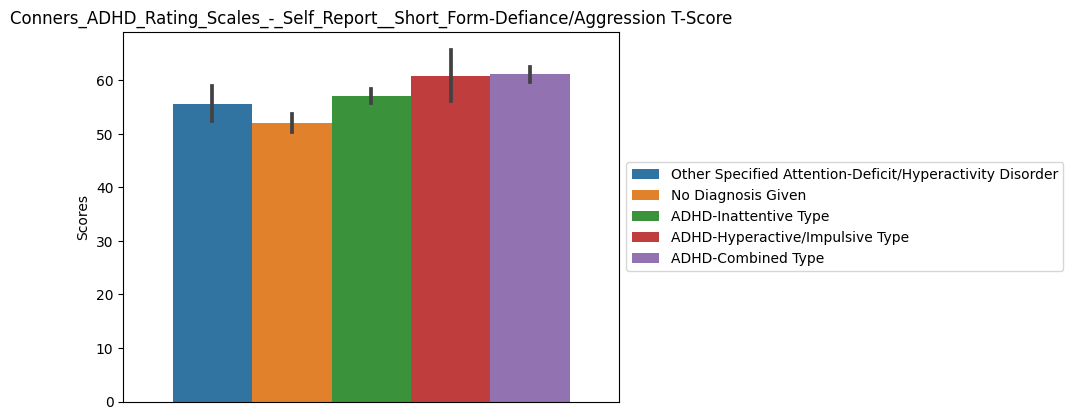

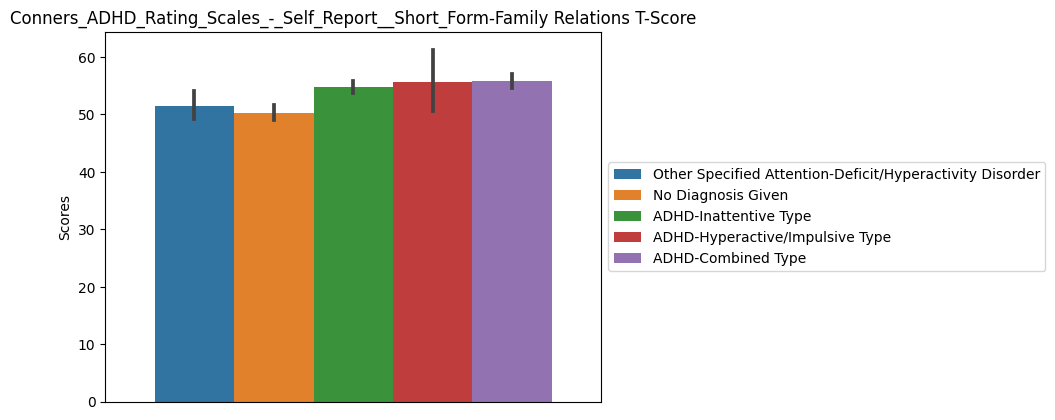

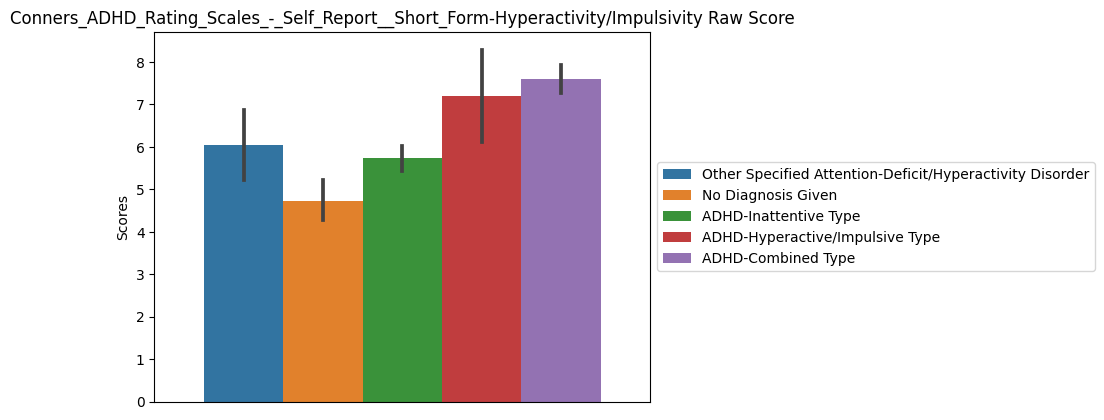

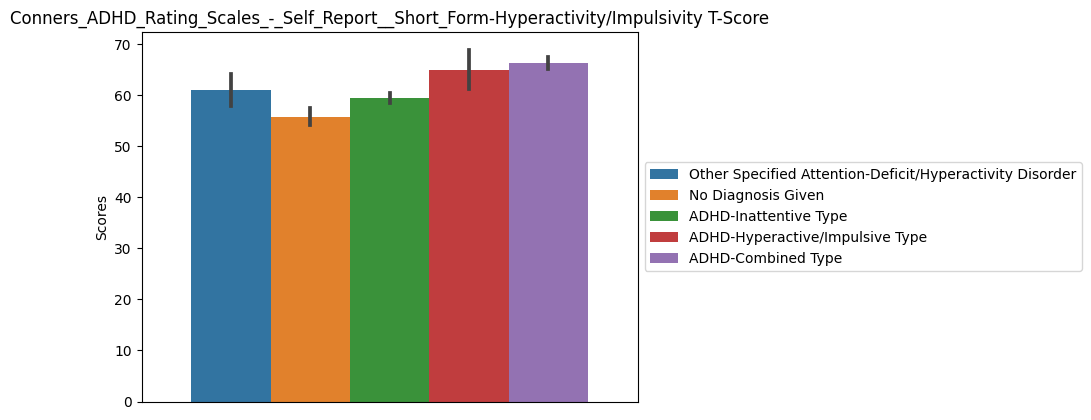

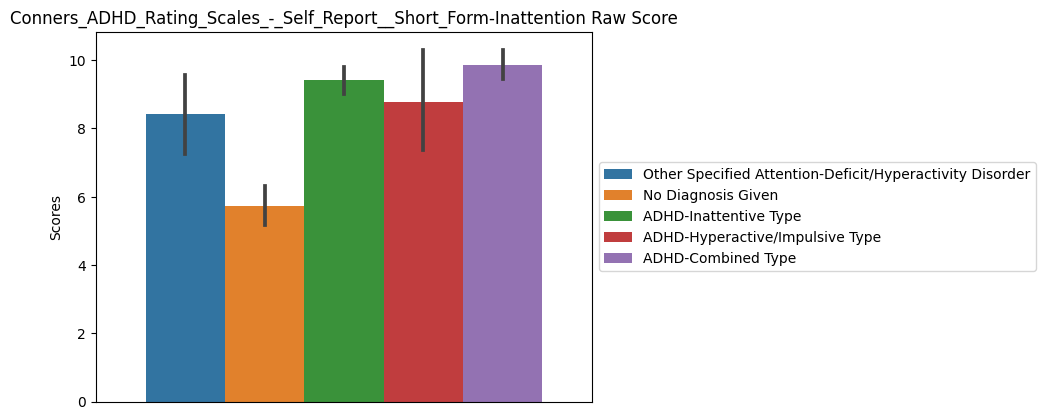

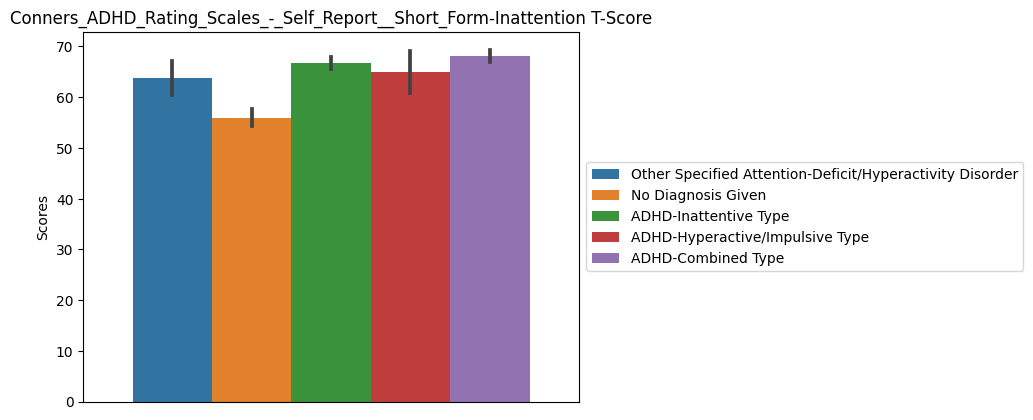

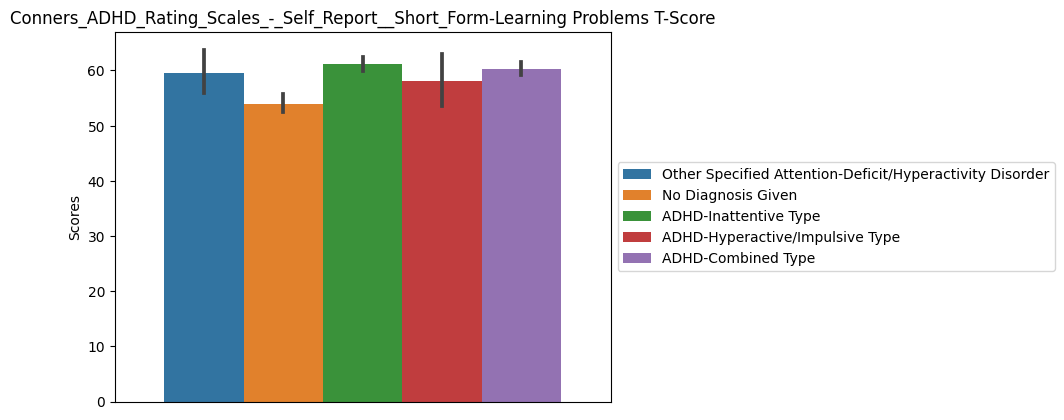

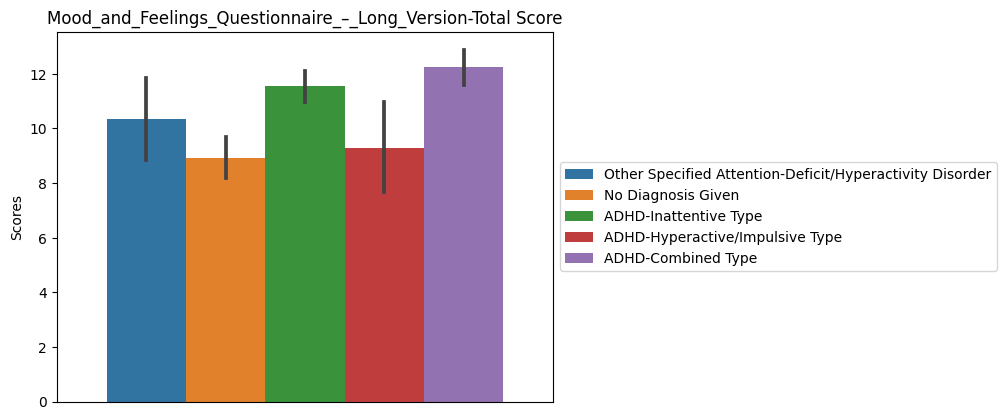

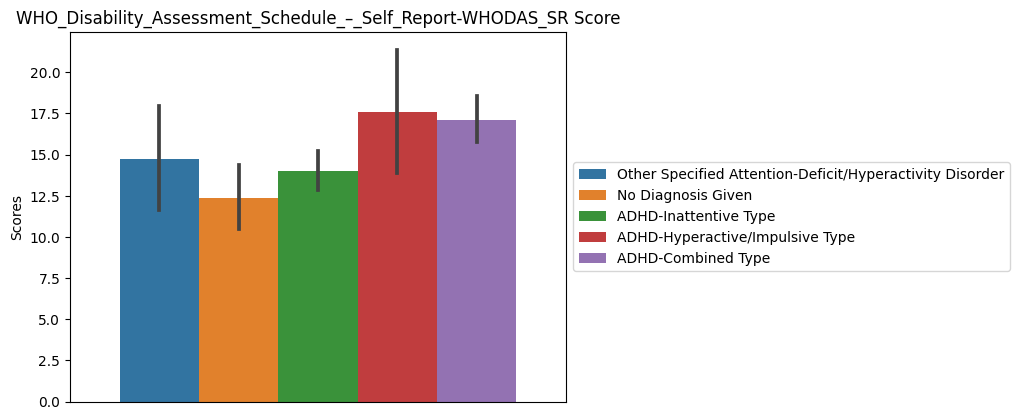

In [147]:

df = get_data(domain='Questionnaire_Measures_of_Emotional_and_Cognitive_Status')

for name, group in df.groupby(['Question']):
    
    measure = group['measure'].unique()[0]
    
    group = group.dropna(how='any')
    
    try:
        group['Scores'] = group['Scores'].astype(int)
    except:
        group['Scores'] = group['Scores'].factorize()[0] + 1
    
    tmp = group.groupby(['DX_01', 'Sex']).mean().reset_index()
    
    fig = sns.barplot(data=group, x='Question', y='Scores', hue='DX_01')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks([]);
    plt.xlabel('')
    plt.title(f'{measure}-{name}')
    plt.show()
    

for name, group in df.groupby(['Question']):
    
    group = group.dropna(how='any')
    
    try:
        group['Scores'] = group['Scores'].astype(int)
    except:
        group['Scores'] = group['Scores'].factorize()[0] + 1
    
    tmp = group.groupby(['DX_01', 'Sex']).mean().reset_index()

    fig = px.line_polar(tmp, r="Scores", 
                        theta="DX_01", 
                        color="Sex", 
                        line_close=True, 
                        title=f'{measure}-{name}',
                        range_r=[tmp['Scores'].min(), tmp['Scores'].max()]
                       ) 
    fig.show()

In [155]:

df = get_data(domain='Questionnaire_Measures_of_Family_Structure__Stress__and_Trauma')

for name, group in df.groupby(['Question']):
    
    measure = group['measure'].unique()[0]
    
    group = group.dropna(how='any')
    
    try:
        group['Scores'] = group['Scores'].astype(int)
    except:
        group['Scores'] = group['Scores'].factorize()[0] + 1
    
    tmp = group.groupby(['DX_01', 'Sex']).mean().reset_index()
    
    fig = sns.barplot(data=group, x='Question', y='Scores', hue='DX_01')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks([]);
    plt.xlabel('')
    plt.title(f'{measure}-{name}')
    plt.show()
    

for name, group in df.groupby(['Question']):
    
    group = group.dropna(how='any')
    
    try:
        group['Scores'] = group['Scores'].astype(int)
    except:
        group['Scores'] = group['Scores'].factorize()[0] + 1
    
    tmp = group.groupby(['DX_01', 'Sex']).mean().reset_index()

    fig = px.line_polar(tmp, r="Scores", 
                        theta="DX_01", 
                        color="Sex", 
                        line_close=True, 
                        title=f'{measure}-{name}',
                        range_r=[tmp['Scores'].min(), tmp['Scores'].max()]
                       ) 
    fig.show()

/Users/maedbhking/Documents/healthy_brain_network/features/features-Child_Measures-Questionnaire_Measures_of_Family_Structure__Stress__and_Trauma-PhenX_School_Risk-spec.json
/Users/maedbhking/Documents/healthy_brain_network/features/features-Child_Measures-Questionnaire_Measures_of_Family_Structure__Stress__and_Trauma-Children’s_Perception_of_Interparental_Conflict-spec.json
/Users/maedbhking/Documents/healthy_brain_network/features/features-Child_Measures-Questionnaire_Measures_of_Family_Structure__Stress__and_Trauma-Children’s_Coping_Strategies_Checklist-Revised_-spec.json
/Users/maedbhking/Documents/healthy_brain_network/features/features-Child_Measures-Questionnaire_Measures_of_Family_Structure__Stress__and_Trauma-Alabama_Parenting_Questionnaire_-spec.json


KeyError: 'Question'

In [168]:
domain = 'Questionnaire_Measures_of_Family_Structure__Stress__and_Trauma'

participants = make_dataset.get_participants(
                            split='all', 
                            disorders=['ADHD-Combined Type', 
                                        'ADHD-Inattentive Type', 
                                        'ADHD-Hyperactive_Impulsive_Type', 
                                        'Other_Specified_Attention-Deficit_Hyperactivity_Disorder',
                                        'No_Diagnosis_Given']
                                        )
# loop over domains
feature_specs = glob.glob(os.path.join(Defaults.FEATURE_DIR, f'*{domain}*'))

# loop over feature specs 
df_all = pd.DataFrame()
for feature_spec in feature_specs:
    df = make_dataframe(
                        feature_spec=feature_spec,
                        participants=participants,
                        cols_to_keep='Identifiers|DX_01|Age|Sex|DX_01_Cat',
                        filter_scores=True,
                        )
    df_all = pd.concat([df_all, df])
    print(feature_spec)

/Users/maedbhking/Documents/healthy_brain_network/features/features-Child_Measures-Questionnaire_Measures_of_Family_Structure__Stress__and_Trauma-PhenX_School_Risk-spec.json
/Users/maedbhking/Documents/healthy_brain_network/features/features-Child_Measures-Questionnaire_Measures_of_Family_Structure__Stress__and_Trauma-Children’s_Perception_of_Interparental_Conflict-spec.json
/Users/maedbhking/Documents/healthy_brain_network/features/features-Child_Measures-Questionnaire_Measures_of_Family_Structure__Stress__and_Trauma-Children’s_Coping_Strategies_Checklist-Revised_-spec.json
/Users/maedbhking/Documents/healthy_brain_network/features/features-Child_Measures-Questionnaire_Measures_of_Family_Structure__Stress__and_Trauma-Alabama_Parenting_Questionnaire_-spec.json


In [172]:
filter_scores = True

cols_to_keep='Identifiers|DX_01|Age|Sex|DX_01_Cat'

# get data
list_of_cols = list(cols_to_keep.split('|'))
df = load_data(participants, 
             feature_spec=feature_spec,
             cols_to_keep=list_of_cols
             )


# get assessment, domain, measure names
feature_spec_split = Path(feature_spec).name.split('-')
assessment, domain, measure = feature_spec_split[1], feature_spec_split[2], '-'.join(feature_spec_split[3:-1])

df_all = pd.DataFrame()
if len(df.columns) > len(list_of_cols): 

    # get abbrev from dataframe based on default columns
    dict_present = False
    abbrev = df.filter(regex='Site|EID|START_DATE|Data_entry|Year').columns[0].split(',')[0]
    fpath = os.path.join(Defaults.PHENO_DIR, 'Release9_DataDic', abbrev + '.xlsx')
    if os.path.isfile(fpath):
        dict_df = pd.read_excel(fpath, header=1)
        dict_present = True

    # only process data that have accompanying dictionaires
    if dict_present:

        # remove prefix from variable values - always second column in data dic
        dict_df.rename(columns={dict_df.columns[0]: "Question", dict_df.columns[1]: "Variable"}, inplace=True)

        # filter dataframe on certain columns and regex patterns
        df_filter = df.filter(regex=f'{abbrev}|{cols_to_keep}')

        # loop over diagnosis groups and melt `T_scores` column into one
        # concat each group to one dataframe
        for name, group in df_filter.groupby('DX_01'):
            if filter_scores:
                scores_to_filter = '_T|_Stnd|_Sum|_Score|_Scale|_Standard|_IN|_HY'
                group = group.filter(regex=f'{scores_to_filter}|{cols_to_keep}')
            tmp = group.melt(id_vars=list(cols_to_keep.split('|'))).rename({'variable':'Name', 'value': 'Scores'}, axis=1)
            tmp['Name'] = tmp['Name'].str.replace(f'{abbrev},','')
            tmp = tmp.merge(dict_df[['Question', 'Variable']], left_on=['Name'], right_on=['Variable'])
            tmp['Assessment'], tmp['domain'], tmp['measure'] = assessment, domain, measure
            df_all = pd.concat([tmp, df_all])

        # do some clean up on existing columns
        df_all['Age_rounded'] = df_all['Age'].round()
        df_all['Question'] = df_all['Question'].str.replace("T Score", "T-Score")

In [178]:
df = phenotype_features(target_spec=None,
                        feature_spec=os.path.join(Defaults.FEATURE_DIR, feature_spec),
                        participants=participants,
                        preprocess=False,
                        drop_identifiers=False
                        )

In [182]:
feature_spec


'/Users/maedbhking/Documents/healthy_brain_network/features/features-Child_Measures-Questionnaire_Measures_of_Family_Structure__Stress__and_Trauma-Alabama_Parenting_Questionnaire_-spec.json'

In [177]:
# get summary of clinical diagnosis + other demographics
dx = make_dataset.make_summary(save=False)
dx = make_dataset._add_race_ethnicity(dataframe=dx)

cols_to_keep = list(cols_to_keep.split('|'))
# get data from intake interview and merge with clinical summary
df = df.merge(dx[cols_to_keep], on='Identifiers')

,Identifiers,DX_01,Age,Sex,DX_01_Cat
0,NDARBM433VER,ADHD-Combined Type,9.504677,male,Neurodevelopmental Disorders
1,NDARCD401HGZ,No Diagnosis Given,18.914099,male,No Diagnosis Given
2,NDARCM811CV1,ADHD-Inattentive Type,17.674652,male,Neurodevelopmental Disorders
3,NDARCP292KPA,ADHD-Inattentive Type,20.297399,male,Neurodevelopmental Disorders
4,NDARDX770PJK,ADHD-Combined Type,21.715035,female,Neurodevelopmental Disorders
...,...,...,...,...,...
1970,NDARYV654UGB,ADHD-Inattentive Type,7.207734,male,Neurodevelopmental Disorders
1971,NDARYZ433UL5,ADHD-Hyperactive/Impulsive Type,5.827743,male,Neurodevelopmental Disorders
1972,NDARZL162HZH,ADHD-Inattentive Type,10.090006,male,Neurodevelopmental Disorders
1973,NDARZX667AT5,ADHD-Inattentive Type,7.127880,male,Neurodevelopmental Disorders
